#### Customer Churn Prediction

#### importing important libraries

In [3]:
#importing important libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#### Load Dataset

In [4]:
#Load Dataset

df=pd.read_csv(r"C:\jupyter notebook\Customer churn prediction system\Telco_Customer_Churn_Dataset  (3).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Data Cleaning

In [8]:
#df.dropna(inplace = True)

#### Encoding Categorical Data
converting text data into numerical data for ML model

In [9]:
####
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

#### Split Data
slpiting data 20% for testing and 80% for training 

In [22]:
X = df.drop(["Churn",'customerID'], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Model Training Part 
training Random Forest model

In [23]:
# model = RandomForestClassifier()
# model.fit(X_train, y_train)

# model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
# model.fit(X_train, y_train)


model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,      
    max_depth=10,          # Overfitting rokta hai
    min_samples_leaf=4,    # Overfitting rokta hai
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### prediction
Taking Prediction on Test Data

In [24]:
y_pred = model.predict(X_test)

#### Evaluation

In [25]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))

Accuracy:  0.7863733144073811
              precision    recall  f1-score   support

           0       0.90      0.79      0.85      1036
           1       0.57      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.79      1409



In [26]:
y_pred_tuned = (model.predict_proba(X_test)[:, 1] >= 0.35).astype(int)

print("Tuned Threshold Results:")
print(classification_report(y_test, y_pred_tuned))

Tuned Threshold Results:
              precision    recall  f1-score   support

           0       0.94      0.66      0.78      1036
           1       0.48      0.88      0.63       373

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.82      0.72      0.74      1409



#### Feature Importance

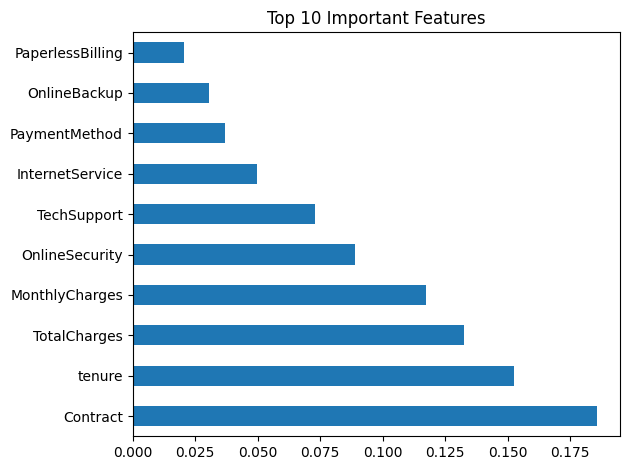

In [27]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

#### Confusion matrix
Visualize the performance of the model

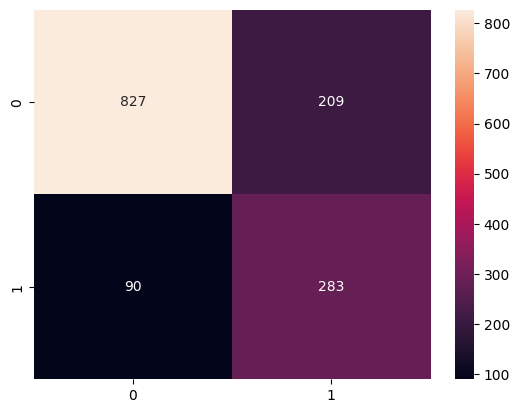

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True ,fmt='d')
plt.show()

#### EDA 

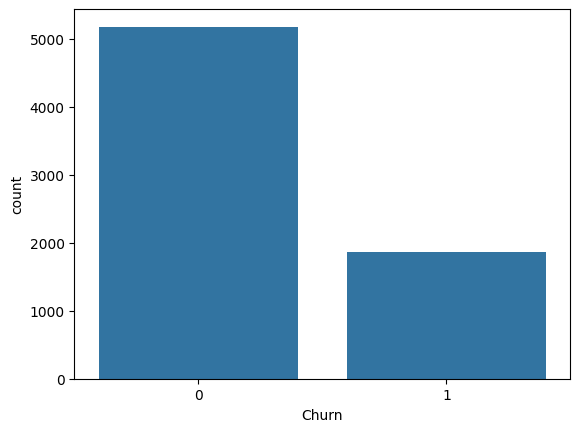

In [18]:
sns.countplot(x="Churn", data=df)
plt.show()

## Observation:
The number of non-churn customers is higher than churn customers.

## Interpretation:
The dataset is imbalanced, with a majority of customers staying with the company.

## Business Insight:
The company should still focus on reducing churn, as even a smaller churn percentage can significantly impact revenue.

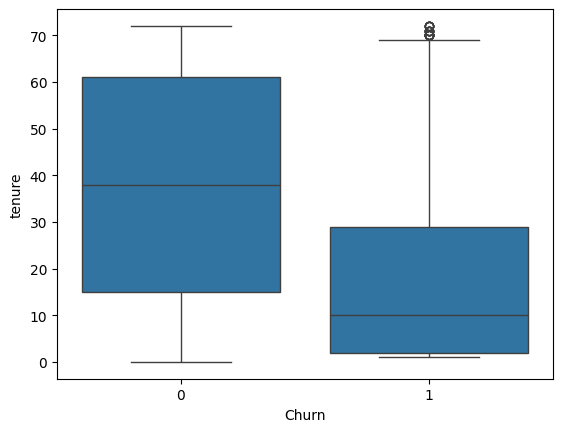

In [19]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

## Observation:
Customers with lower tenure are more likely to churn compared to long-term customers.

## Interpretation:
New customers tend to leave early, possibly due to dissatisfaction or unmet expectations.

## Business Insight:
Improving onboarding and early customer engagement can help reduce churn.

In [20]:
# print(df['Churn'].value_counts(normalize=True))